In [39]:
import numpy as np
import pandas as pd

In [40]:
df = pd.read_csv('/content/football_weather_dataset_600.csv')

In [41]:
df

,Day,Outlook,Temperature,Humidity,Wind,Play_Football
0,D1,Rainy,Hot,High,Strong,No
1,D2,Sunny,Hot,High,Weak,No
2,D3,Rainy,Cool,High,Strong,No
3,D4,Sunny,Hot,High,Weak,No
4,D5,Sunny,Cool,High,Weak,No
...,...,...,...,...,...,...
595,D596,Rainy,Cool,Normal,Strong,No
596,D597,Sunny,Mild,High,Weak,No
597,D598,Overcast,Mild,Normal,Weak,Yes
598,D599,Rainy,Cool,High,Strong,No


In [42]:
df.drop(columns=['Day'], inplace=True)

In [43]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,Rainy,Hot,High,Strong,No
1,Sunny,Hot,High,Weak,No
2,Rainy,Cool,High,Strong,No
3,Sunny,Hot,High,Weak,No
4,Sunny,Cool,High,Weak,No


In [44]:
df.tail()

,Outlook,Temperature,Humidity,Wind,Play_Football
595,Rainy,Cool,Normal,Strong,No
596,Sunny,Mild,High,Weak,No
597,Overcast,Mild,Normal,Weak,Yes
598,Rainy,Cool,High,Strong,No
599,Rainy,Mild,High,Strong,No


In [45]:
df.shape

(600, 5)

In [46]:
df.isnull().sum()

,0
Outlook,0
Temperature,0
Humidity,0
Wind,0
Play_Football,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Outlook        600 non-null    object
 1   Temperature    600 non-null    object
 2   Humidity       600 non-null    object
 3   Wind           600 non-null    object
 4   Play_Football  600 non-null    object
dtypes: object(5)
memory usage: 23.6+ KB


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

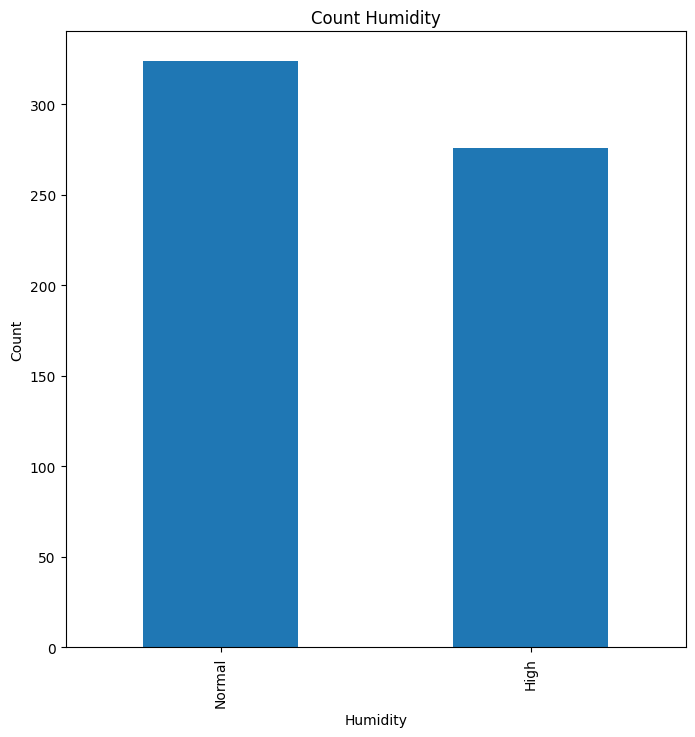

In [49]:
plt.figure(figsize=(8,8))
df['Humidity'].value_counts().plot(kind='bar')
plt.title('Count Humidity')
plt.xlabel('Humidity')
plt.ylabel("Count")
plt.show()

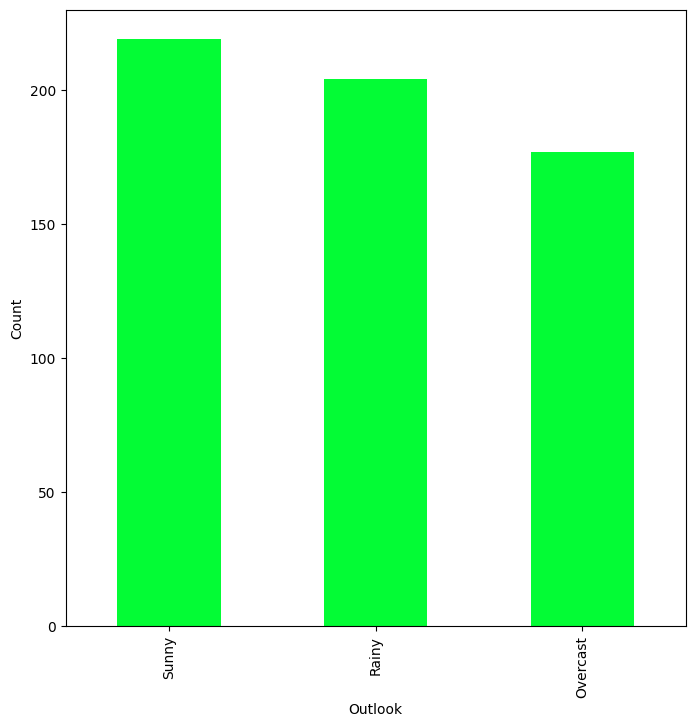

In [58]:
plt.figure(figsize=(8,8))
df['Outlook'].value_counts().plot(kind='bar',color='#03fc35')
plt.ylabel("Count")
plt.show()

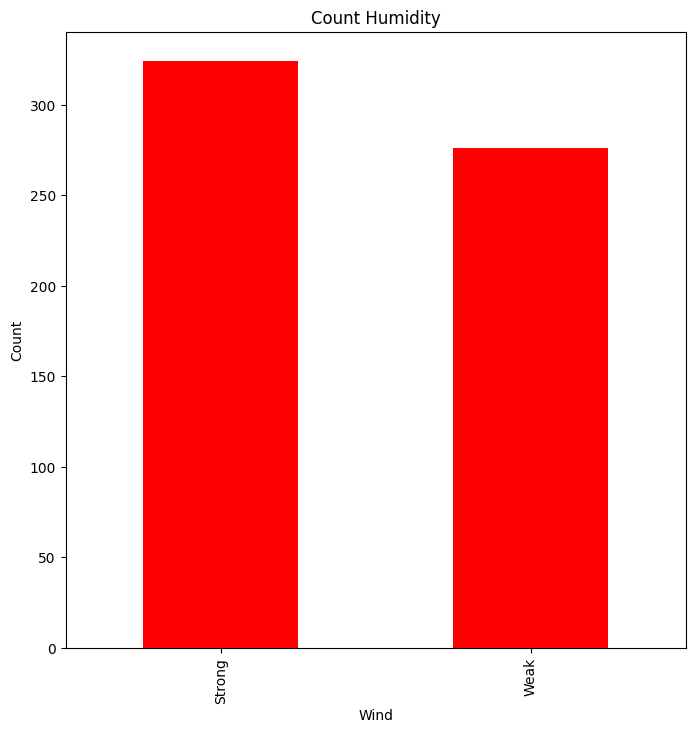

In [59]:
plt.figure(figsize=(8,8))
df['Wind'].value_counts().plot(kind='bar',color='red')
plt.title('Count Humidity')
plt.ylabel("Count")
plt.show()

In [60]:
from sklearn.preprocessing import LabelEncoder

In [61]:
le = LabelEncoder()

In [62]:
df['Outlook'] = le.fit_transform(df['Outlook'])
df['Temperature'] = le.fit_transform(df['Temperature'])
df['Humidity'] = le.fit_transform(df['Humidity'])
df['Wind'] = le.fit_transform(df['Wind'])
df['Play_Football'] = le.fit_transform(df['Play_Football'])

In [63]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,1,1,0,0,0
1,2,1,0,1,0
2,1,0,0,0,0
3,2,1,0,1,0
4,2,0,0,1,0


In [64]:
df.tail()

,Outlook,Temperature,Humidity,Wind,Play_Football
595,1,0,1,0,0
596,2,2,0,1,0
597,0,2,1,1,1
598,1,0,0,0,0
599,1,2,0,0,0


In [78]:
X = df.drop(columns=['Play_Football'],axis=1)
y = df['Play_Football']

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [99]:
from sklearn.tree import DecisionTreeClassifier

In [100]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [101]:
y_pred = model.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report

In [110]:
acc = accuracy_score(y_test,y_pred)
print(f'the accuracy score is {acc*100}')

the accuracy score is 91.66666666666666


In [107]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.82      0.90        55
           1       0.87      1.00      0.93        65

    accuracy                           0.92       120
   macro avg       0.93      0.91      0.91       120
weighted avg       0.93      0.92      0.92       120

